In [1]:
import numpy as np
import os
from os.path import isfile
import keras
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Bidirectional, LSTM, Dropout, Activation, GRU
from keras.layers import Conv2D, concatenate, MaxPooling2D, Flatten, Embedding, Lambda


from keras.callbacks import ModelCheckpoint, TensorBoard, ReduceLROnPlateau
from keras import backend as K
from keras.utils import np_utils
from keras.optimizers import Adam, RMSprop
from glob import glob
from keras import regularizers

import matplotlib.pyplot as plt

import librosa
import librosa.display

import seaborn as sns


In [2]:
AUDIO_DIR = "audios/labeled/"

dict_genres = {'positive': 0, 'negative': 1, 'noise': 2}

reverse_map = {v: k for k, v in dict_genres.items()}
print(reverse_map)

{0: 'positive', 1: 'negative', 2: 'noise'}


(107, 128)


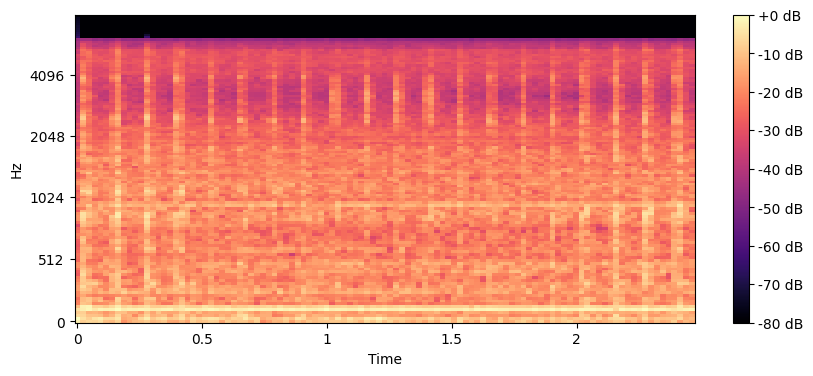

In [5]:
def get_audio_path(track_id):
    for label in dict_genres.keys():
        for folder in os.listdir(AUDIO_DIR + label):
            for file in os.listdir(AUDIO_DIR + label + "/" + folder):
                if file[:-4] == track_id:
                    return AUDIO_DIR + label + "/" + folder + "/" + file


def create_spectogram(track_id):
    audio_path = get_audio_path(track_id)
    y, sr = librosa.load(audio_path)
    spect = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=2048, hop_length=1024)
    spect = librosa.power_to_db(spect, ref=np.max)
    return spect.T

def plot_spect(track_id):
    spect = create_spectogram(track_id)
    print(spect.shape)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(spect.T, y_axis='mel', fmax=8000, x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.show()

plot_spect("000301")


In [4]:
batch_size = 32
num_classes = 8
n_features = X_train.shape[2]
n_time = X_train.shape[1]


NameError: name 'X_train' is not defined

In [ ]:
nb_filters1 = 16
nb_filters2 = 32
nb_filters3 = 64
nb_filters4 = 64
nb_filters5 = 64
ksize = (3, 1)
pool_size_1 = (2, 2)
pool_size_2 = (4, 4)
pool_size_3 = (4, 2)

dropout_prob = 0.20
dense_size1 = 128
lstm_count = 64
num_units = 120

BATCH_SIZE = 64
EPOCH_COUNT = 50
L2_regularization = 0.001

def conv_recurrent_model_build(model_input):
    print('Building model...')
    layer = model_input

    ### Convolutional blocks
    conv_1 = Conv2D(filters=nb_filters1, kernel_size=ksize, strides=1,
                    padding='valid', activation='relu', name='conv_1')(layer)
    pool_1 = MaxPooling2D(pool_size_1)(conv_1)

    conv_2 = Conv2D(filters=nb_filters2, kernel_size=ksize, strides=1,
                    padding='valid', activation='relu', name='conv_2')(pool_1)
    pool_2 = MaxPooling2D(pool_size_1)(conv_2)

    conv_3 = Conv2D(filters=nb_filters3, kernel_size=ksize, strides=1,
                    padding='valid', activation='relu', name='conv_3')(pool_2)
    pool_3 = MaxPooling2D(pool_size_1)(conv_3)

    conv_4 = Conv2D(filters=nb_filters4, kernel_size=ksize, strides=1,
                    padding='valid', activation='relu', name='conv_4')(pool_3)
    pool_4 = MaxPooling2D(pool_size_2)(conv_4)

    conv_5 = Conv2D(filters=nb_filters5, kernel_size=ksize, strides=1,
                    padding='valid', activation='relu', name='conv_5')(pool_4)
    pool_5 = MaxPooling2D(pool_size_2)(conv_5)

    flatten1 = Flatten()(pool_5)
    ### Recurrent Block

    # Pooling layer
    pool_lstm1 = MaxPooling2D(pool_size_3, name='pool_lstm')(layer)

    # Embedding layer

    squeezed = Lambda(lambda x: K.squeeze(x, axis=-1))(pool_lstm1)
#     flatten2 = K.squeeze(pool_lstm1, axis = -1)
#     dense1 = Dense(dense_size1)(flatten)

    # Bidirectional GRU
    lstm = Bidirectional(GRU(lstm_count))(
        squeezed)  # default merge mode is concat

    # Concat Output
    concat = concatenate([flatten1, lstm], axis=-1, name='concat')

    ## Softmax Output
    output = Dense(num_classes, activation='softmax', name='preds')(concat)

    model_output = output
    model = Model(model_input, model_output)

#     opt = Adam(lr=0.001)
    opt = RMSprop(lr=0.0005)  # Optimizer
    model.compile(
        loss='categorical_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )

    print(model.summary())
    return model


In [ ]:
def train_model(x_train, y_train, x_val, y_val):

    n_frequency = 128
    n_frames = 640
    #reshape and expand dims for conv2d
#     x_train = x_train.reshape(-1, n_frequency, n_frames)
    x_train = np.expand_dims(x_train, axis=-1)

#     x_val = x_val.reshape(-1, n_frequency, n_frames)
    x_val = np.expand_dims(x_val, axis=-1)

    input_shape = (n_frames, n_frequency, 1)
    model_input = Input(input_shape, name='input')

    model = conv_recurrent_model_build(model_input)

#     tb_callback = TensorBoard(log_dir='./logs/4', histogram_freq=1, batch_size=32, write_graph=True, write_grads=False,
#                               write_images=False, embeddings_freq=0, embeddings_layer_names=None,
#                               embeddings_metadata=None)
    checkpoint_callback = ModelCheckpoint('./models/parallel/weights.best.h5', monitor='val_acc', verbose=1,
                                          save_best_only=True, mode='max')

    reducelr_callback = ReduceLROnPlateau(
        monitor='val_acc', factor=0.5, patience=10, min_delta=0.01,
        verbose=1
    )
    callbacks_list = [checkpoint_callback, reducelr_callback]

    # Fit the model and get training history.
    print('Training...')
    history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCH_COUNT,
                        validation_data=(x_val, y_val), verbose=1, callbacks=callbacks_list)

    return model, history


In [ ]:
def show_summary_stats(history):
    # List all data in history
    print(history.history.keys())

    # Summarize history for accuracy
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

    # Summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()


In [ ]:
model, history = train_model(X_train, y_train, X_valid, y_valid)


In [ ]:
show_summary_stats(history)


In [ ]:
from sklearn.metrics import classification_report

y_true = np.argmax(y_valid, axis=1)
X_valid = np.expand_dims(X_valid, axis=-1)
y_pred = model.predict(X_valid)
y_pred = np.argmax(y_pred, axis=1)
labels = [0, 1, 2, 3, 4, 5, 6, 7]
target_names = dict_genres.keys()

print(y_true.shape, y_pred.shape)
print(classification_report(y_true, y_pred, target_names=target_names))


In [ ]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_true, y_pred))
